# Análisis Exploratorio

## Carga de archivos

In [15]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_excel('Datos.xlsx', sheet_name='Datos')
df.to_csv('Datos.csv', index=False, encoding='utf-8-sig')

In [16]:
print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
df.head()

Filas: 161,036  |  Columnas: 13


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


In [17]:
df.dtypes

Año                        int64
Mes cod                    int64
Mes                       object
Vía                       object
Frontera                  object
País                      object
Región                    object
Región dos                object
Regiones OMT              object
MCEO                      object
Agrupación Residencia     object
Tipo de Viajero           object
Viajero                  float64
dtype: object

In [18]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Año,161036.0,NaN,NaN,NaN,2016.017543,4.552887,2009.0,2012.0,2016.0,2019.0,2026.0
Mes cod,161036.0,NaN,NaN,NaN,6.416075,3.531936,1.0,3.0,6.0,10.0,12.0
Mes,161036,12,Ene,14726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vía,161036,3,Terrestre,125873,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Frontera,161036,22,01 La Aurora,21424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
País,161036,235,Guatemala,6319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Región,161036,17,EUROPA,32331,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Región dos,161036,11,Europa,54640,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Regiones OMT,161036,26,AMÉRICA CENTRAL,31362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MCEO,161036,8,08 OTROS,73173,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Construcción de la variable fecha

In [19]:
df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes cod'].astype(str) + '-01')
print("Rango de fechas:", df['Fecha'].min().strftime('%Y-%m'), "a", df['Fecha'].max().strftime('%Y-%m'))
print("Meses cubiertos:", df['Fecha'].nunique())

Rango de fechas: 2009-01 a 2026-06
Meses cubiertos: 210


## Comportamiento temporal del número de viajeros

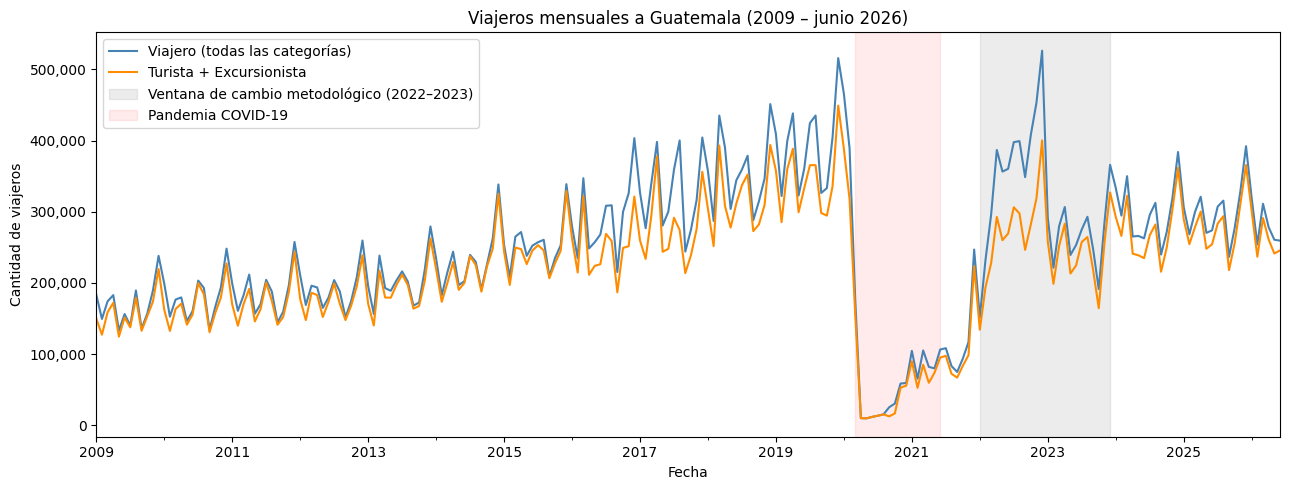

In [20]:
mensual_total = df.groupby('Fecha')['Viajero'].sum()

es_turista_exc = df['Tipo de Viajero'].isin(['Turista', 'Excursionista'])
mensual_turista_exc = df[es_turista_exc].groupby('Fecha')['Viajero'].sum()

fig, ax = plt.subplots(figsize=(13, 5))
mensual_total.plot(ax=ax, label='Viajero (todas las categorías)', color='steelblue')
mensual_turista_exc.plot(ax=ax, label='Turista + Excursionista', color='darkorange')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2023-12-31'), color='gray', alpha=0.15,
           label='Ventana de cambio metodológico (2022–2023)')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'), color='red', alpha=0.08,
           label='Pandemia COVID-19')
ax.set_title('Viajeros mensuales a Guatemala (2009 – junio 2026)')
ax.set_ylabel('Cantidad de viajeros')
ax.set_xlabel('Fecha')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

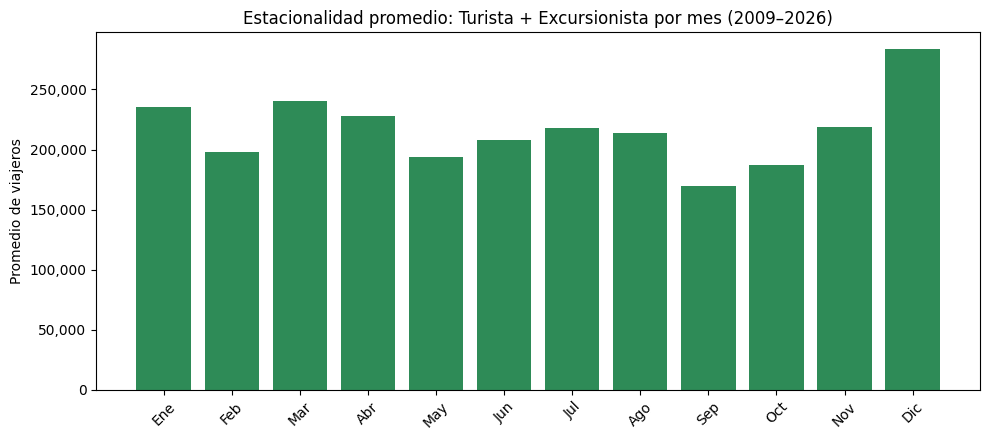

In [21]:
# Estacionalidad: promedio de viajeros (Turista+Excursionista) por mes del año
serie_te = df[es_turista_exc].copy()
prom_mes = serie_te.groupby('Mes cod')['Viajero'].sum().div(serie_te['Año'].nunique())
meses_nombre = serie_te.drop_duplicates('Mes cod').set_index('Mes cod')['Mes'].reindex(prom_mes.index)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(meses_nombre, prom_mes.values, color='seagreen')
ax.set_title('Estacionalidad promedio: Turista + Excursionista por mes (2009–2026)')
ax.set_ylabel('Promedio de viajeros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Países con más viajeros

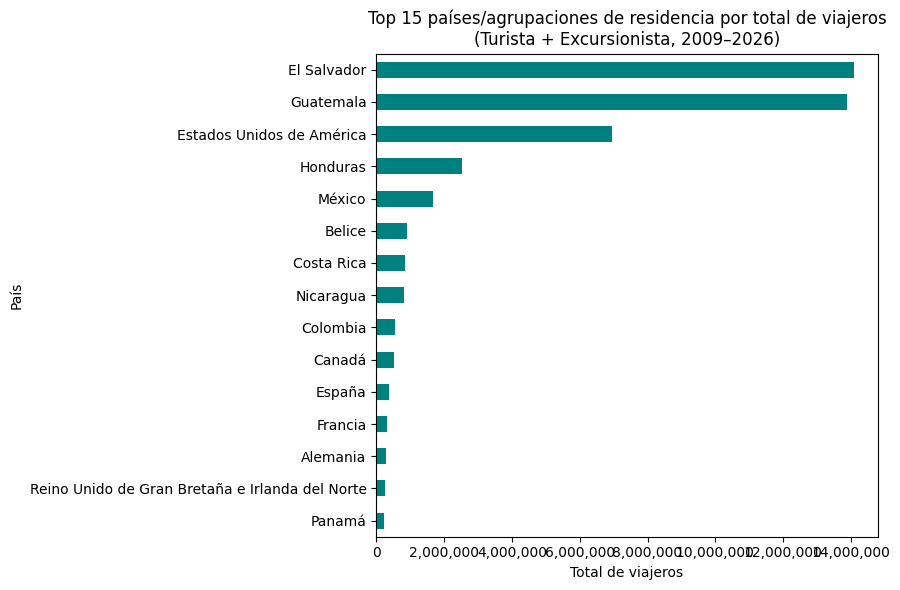

País
El Salvador                                        1.407914e+07
Guatemala                                          1.387039e+07
Estados Unidos de América                          6.965680e+06
Honduras                                           2.520974e+06
México                                             1.678423e+06
Belice                                             9.161011e+05
Costa Rica                                         8.602407e+05
Nicaragua                                          8.111454e+05
Colombia                                           5.494947e+05
Canadá                                             5.167079e+05
España                                             3.885718e+05
Francia                                            3.292003e+05
Alemania                                           2.907738e+05
Reino Unido de Gran Bretaña e Irlanda del Norte    2.595015e+05
Panamá                                             2.259434e+05
Name: Viajero, dtype: float64

In [22]:
top_paises = (df[es_turista_exc].groupby('País')['Viajero'].sum()
              .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 6))
top_paises.sort_values().plot(kind='barh', ax=ax, color='teal')
ax.set_title('Top 15 países/agrupaciones de residencia por total de viajeros\n(Turista + Excursionista, 2009–2026)')
ax.set_xlabel('Total de viajeros')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

top_paises